# Data exploration and analysis

## Imports and setups

In [ ]:
# Import necessary libraries
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import download_dataset, get_dataset_stats
from emotion_classifier.utils import (
    plot_class_distribution, 
    plot_text_length_distribution,
    create_wordcloud,
    create_class_wordclouds,
    plot_top_n_words,
    get_top_n_words
)

In [2]:
# Download dataset if not already downloaded
train_df, test_df = download_dataset()

# Display basic information
print(f"Train data shape: {train_df.shape}")
if test_df is not None:
    print(f"Test data shape: {test_df.shape}")
else:
    print("No separate test data provided")

# Examine the first few rows
train_df.head()

Train data shape: (1874, 8)
No separate test data provided


,text,primary_emotion,secondary_emotions,meta_emotions,sentiment,interaction_style,intensity,context
0,I’m proud of my friend for overcoming her stru...,Admiration,"[Envy, Guilt]","[Pride about admiration, Shame about envy]",Mixed,Reflective,4,Relationships
1,Finally finished that project! It was exhausti...,Relief,"[Joy, Pride]",[Contentment about relief],Positive,Assertive,5,Career
2,The laughter we shared during our reunion was ...,Nostalgia,"[Joy, Bittersweetness]",[Gratitude about joy],Positive,Supportive,6,Relationships
3,Why does everything feel so uncertain right no...,Uncertainty,"[Anxiety, Frustration]",[Vulnerability about uncertainty],Ambiguous,Conflicted,5,Self-Reflection
4,Graduation feels both exciting and sad. It’s t...,Bittersweetness,"[Joy, Sadness]","[Pride about accomplishment, Nostalgia about e...",Mixed,Supportive,6,Education


### Basic Statistics

In [3]:
# Get column info
train_df.info()

# Get basic dataset stats
stats = get_dataset_stats(train_df)
for key, value in stats.items():
    print(f"{key}: {value}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   text                1874 non-null   object
 1   primary_emotion     1874 non-null   object
 2   secondary_emotions  1874 non-null   object
 3   meta_emotions       1874 non-null   object
 4   sentiment           1874 non-null   object
 5   interaction_style   1874 non-null   object
 6   intensity           1874 non-null   int64 
 7   context             1874 non-null   object
dtypes: int64(1), object(7)
memory usage: 117.3+ KB
Total samples: 1874
Class distribution: {'Mixed': 652, 'Positive': 542, 'Negative': 419, 'Ambiguous': 158, 'Neutral': 103}
Class distribution (%): {'Mixed': 34.79, 'Positive': 28.92, 'Negative': 22.36, 'Ambiguous': 8.43, 'Neutral': 5.5}
Average text length (characters): 148.4274279615795
Average text length (words): 27.55282817502668
Number of unique emotions:

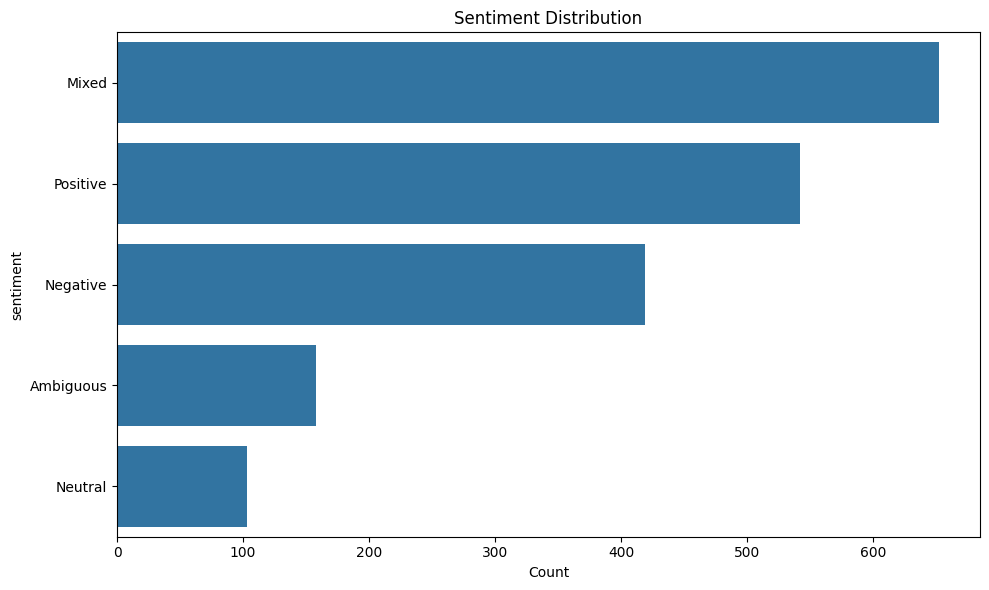

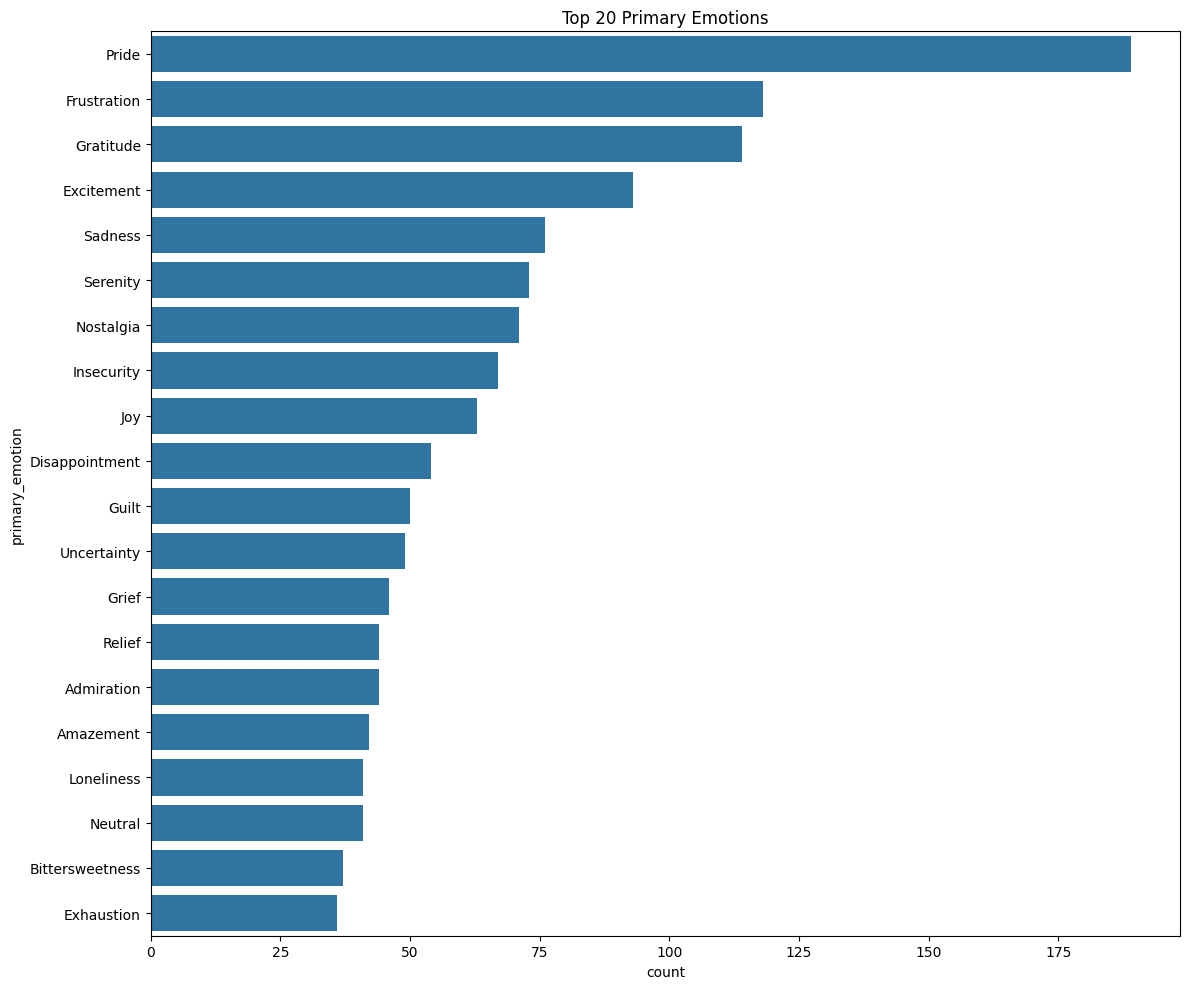

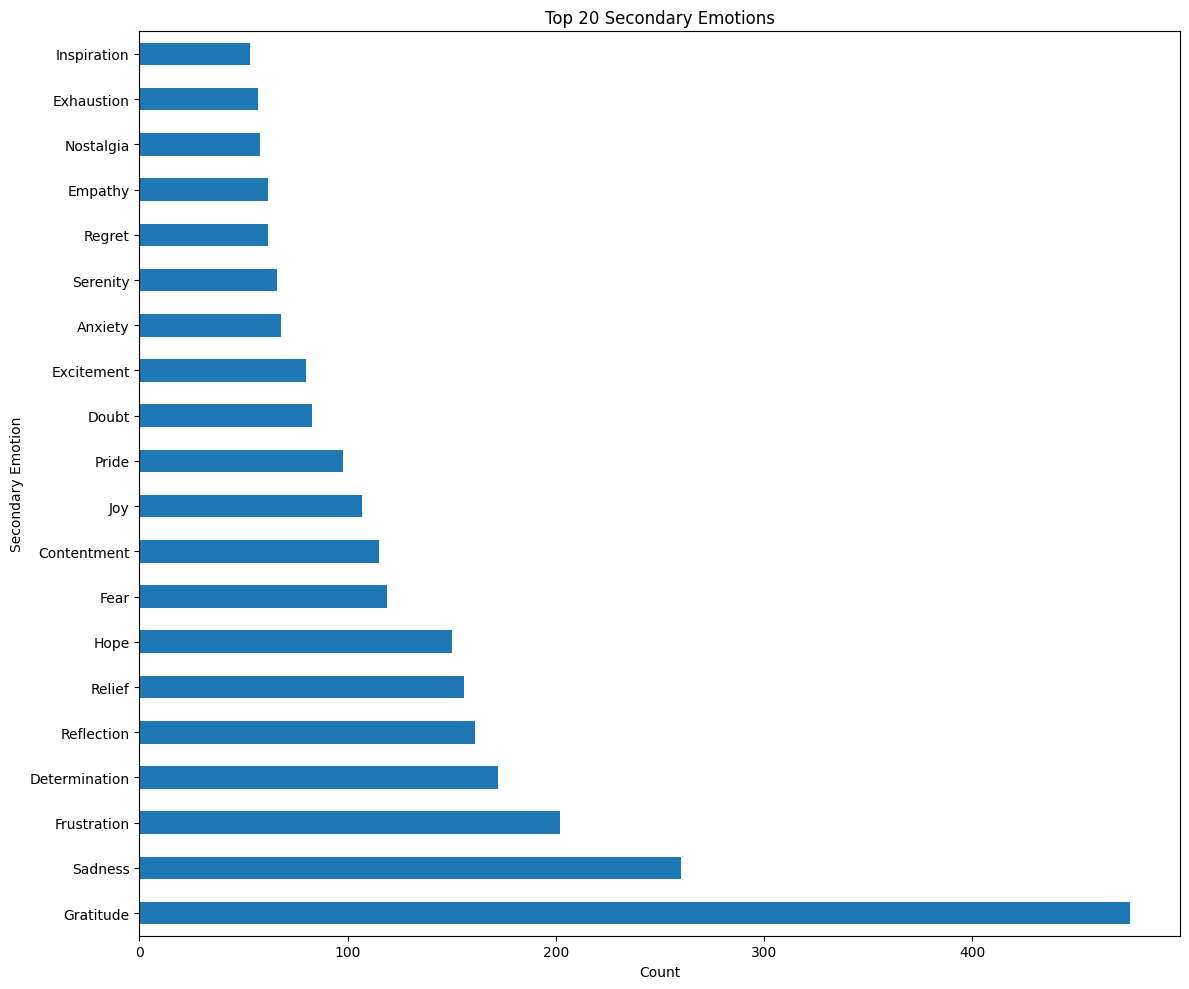

In [4]:
# Plot sentiment distribution
plot_class_distribution(train_df, 'sentiment', title='Sentiment Distribution')

# Plot primary emotion distribution (top 20)
plt.figure(figsize=(12, 10))
sns.countplot(y=train_df['primary_emotion'], order=train_df['primary_emotion'].value_counts().iloc[:20].index)
plt.title('Top 20 Primary Emotions')
plt.tight_layout()
plt.show()

# Calculate secondary emotions frequency
sec_emotions = []
for emotions_list in train_df['secondary_emotions']:
    if isinstance(emotions_list, list):
        sec_emotions.extend(emotions_list)

sec_emotion_counts = pd.Series(sec_emotions).value_counts()

# Plot secondary emotions distribution (top 20)
plt.figure(figsize=(12, 10))
sec_emotion_counts.iloc[:20].plot(kind='barh')
plt.title('Top 20 Secondary Emotions')
plt.xlabel('Count')
plt.ylabel('Secondary Emotion')
plt.tight_layout()
plt.show()

# Text characteristics

First with stop words, and then the same plots but without the stop words

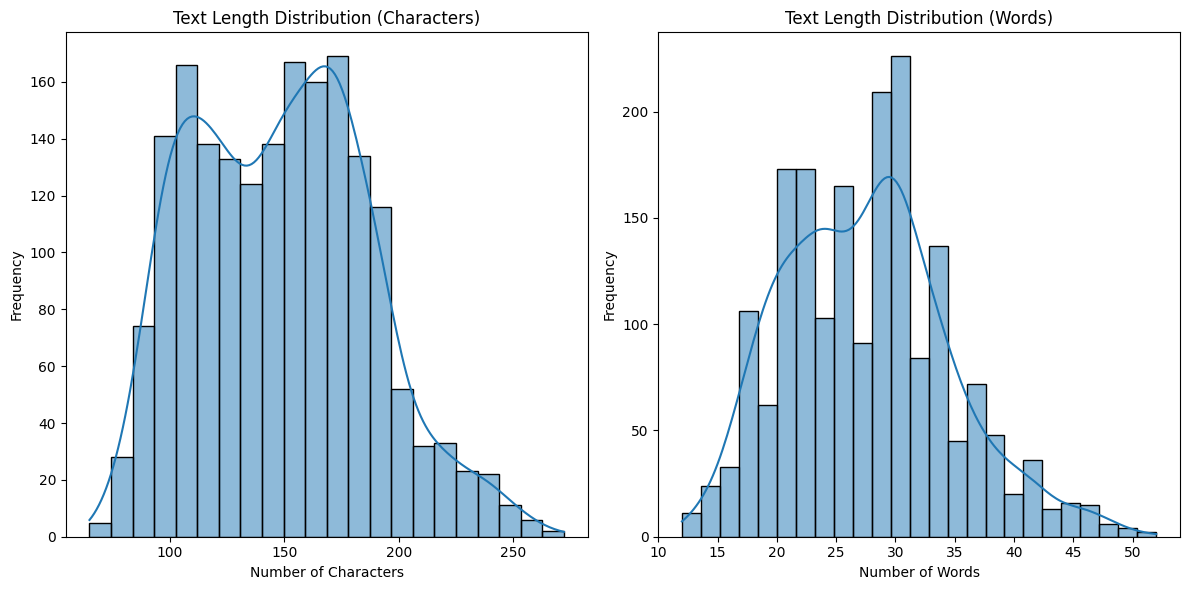

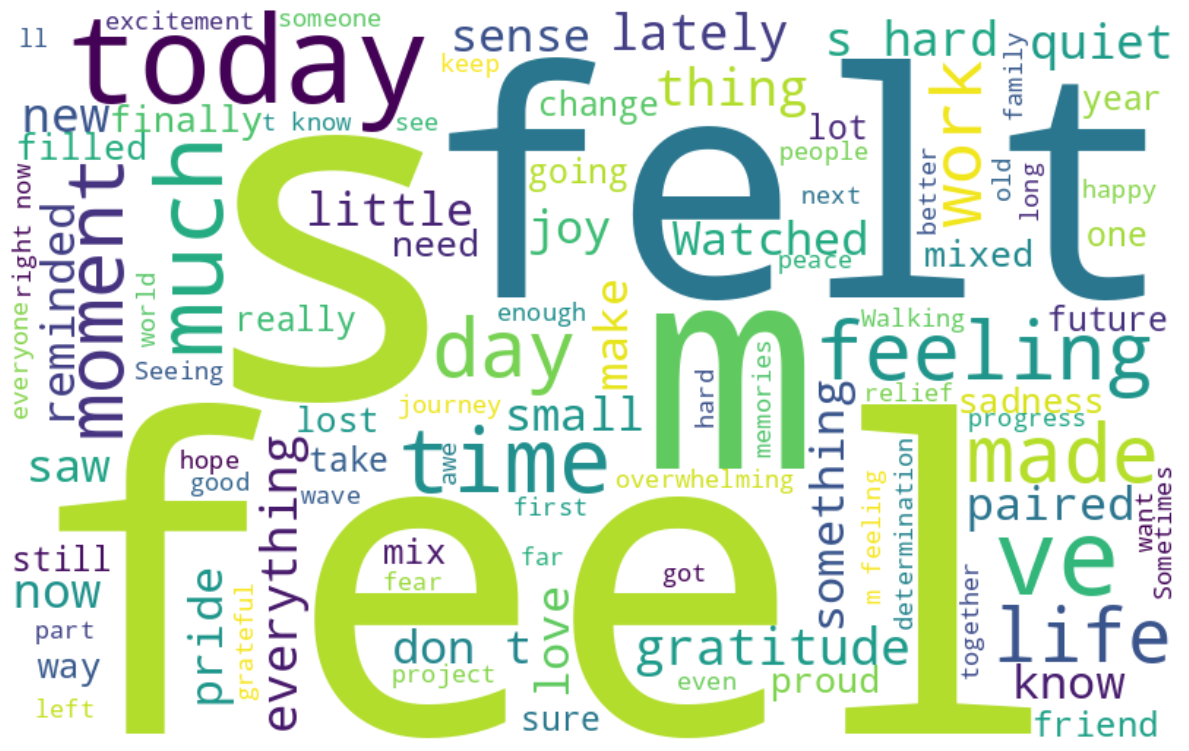

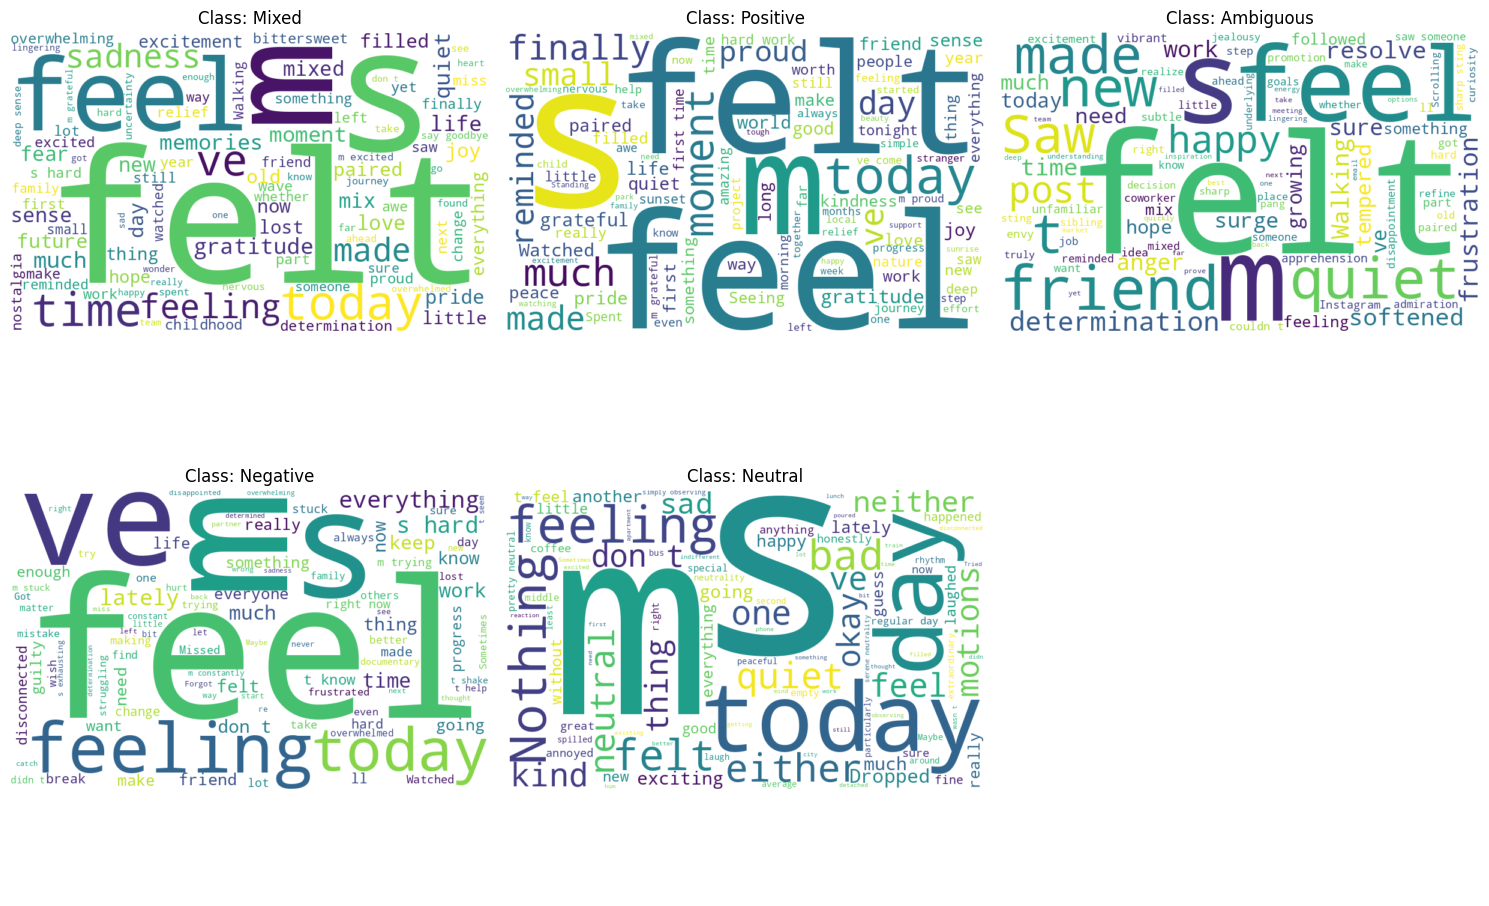

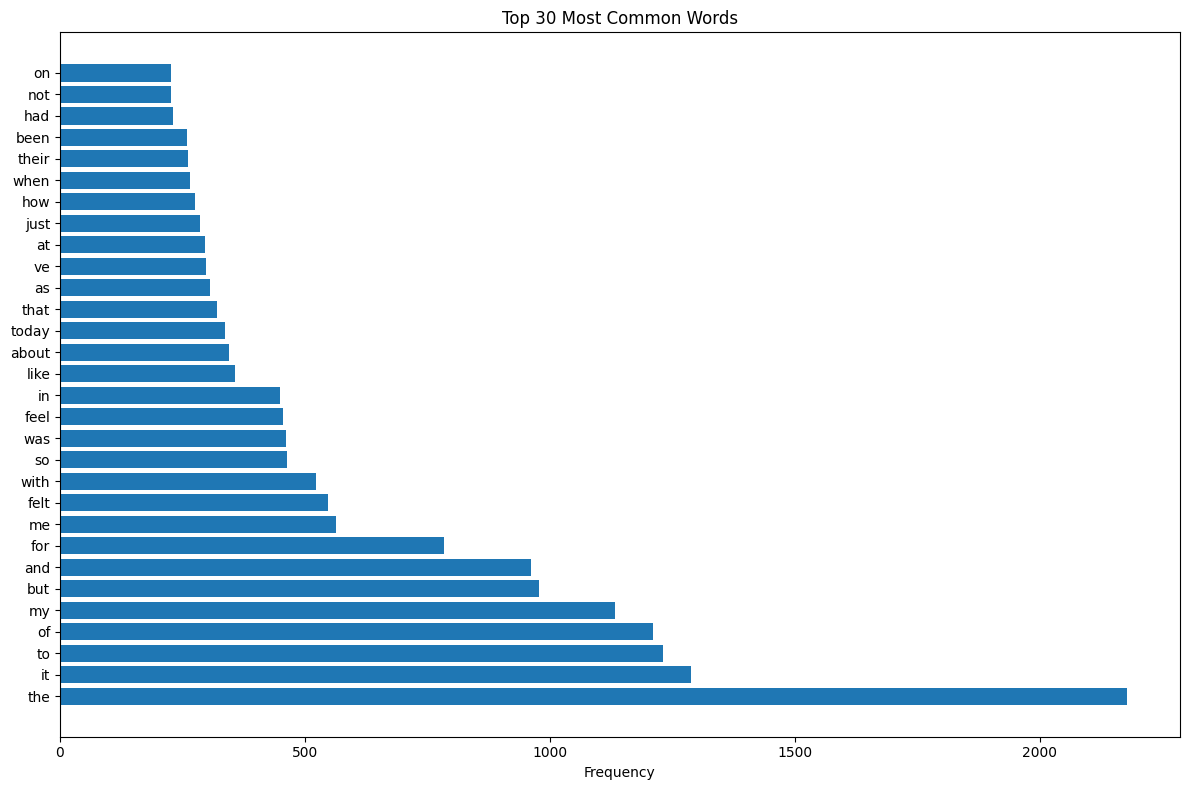

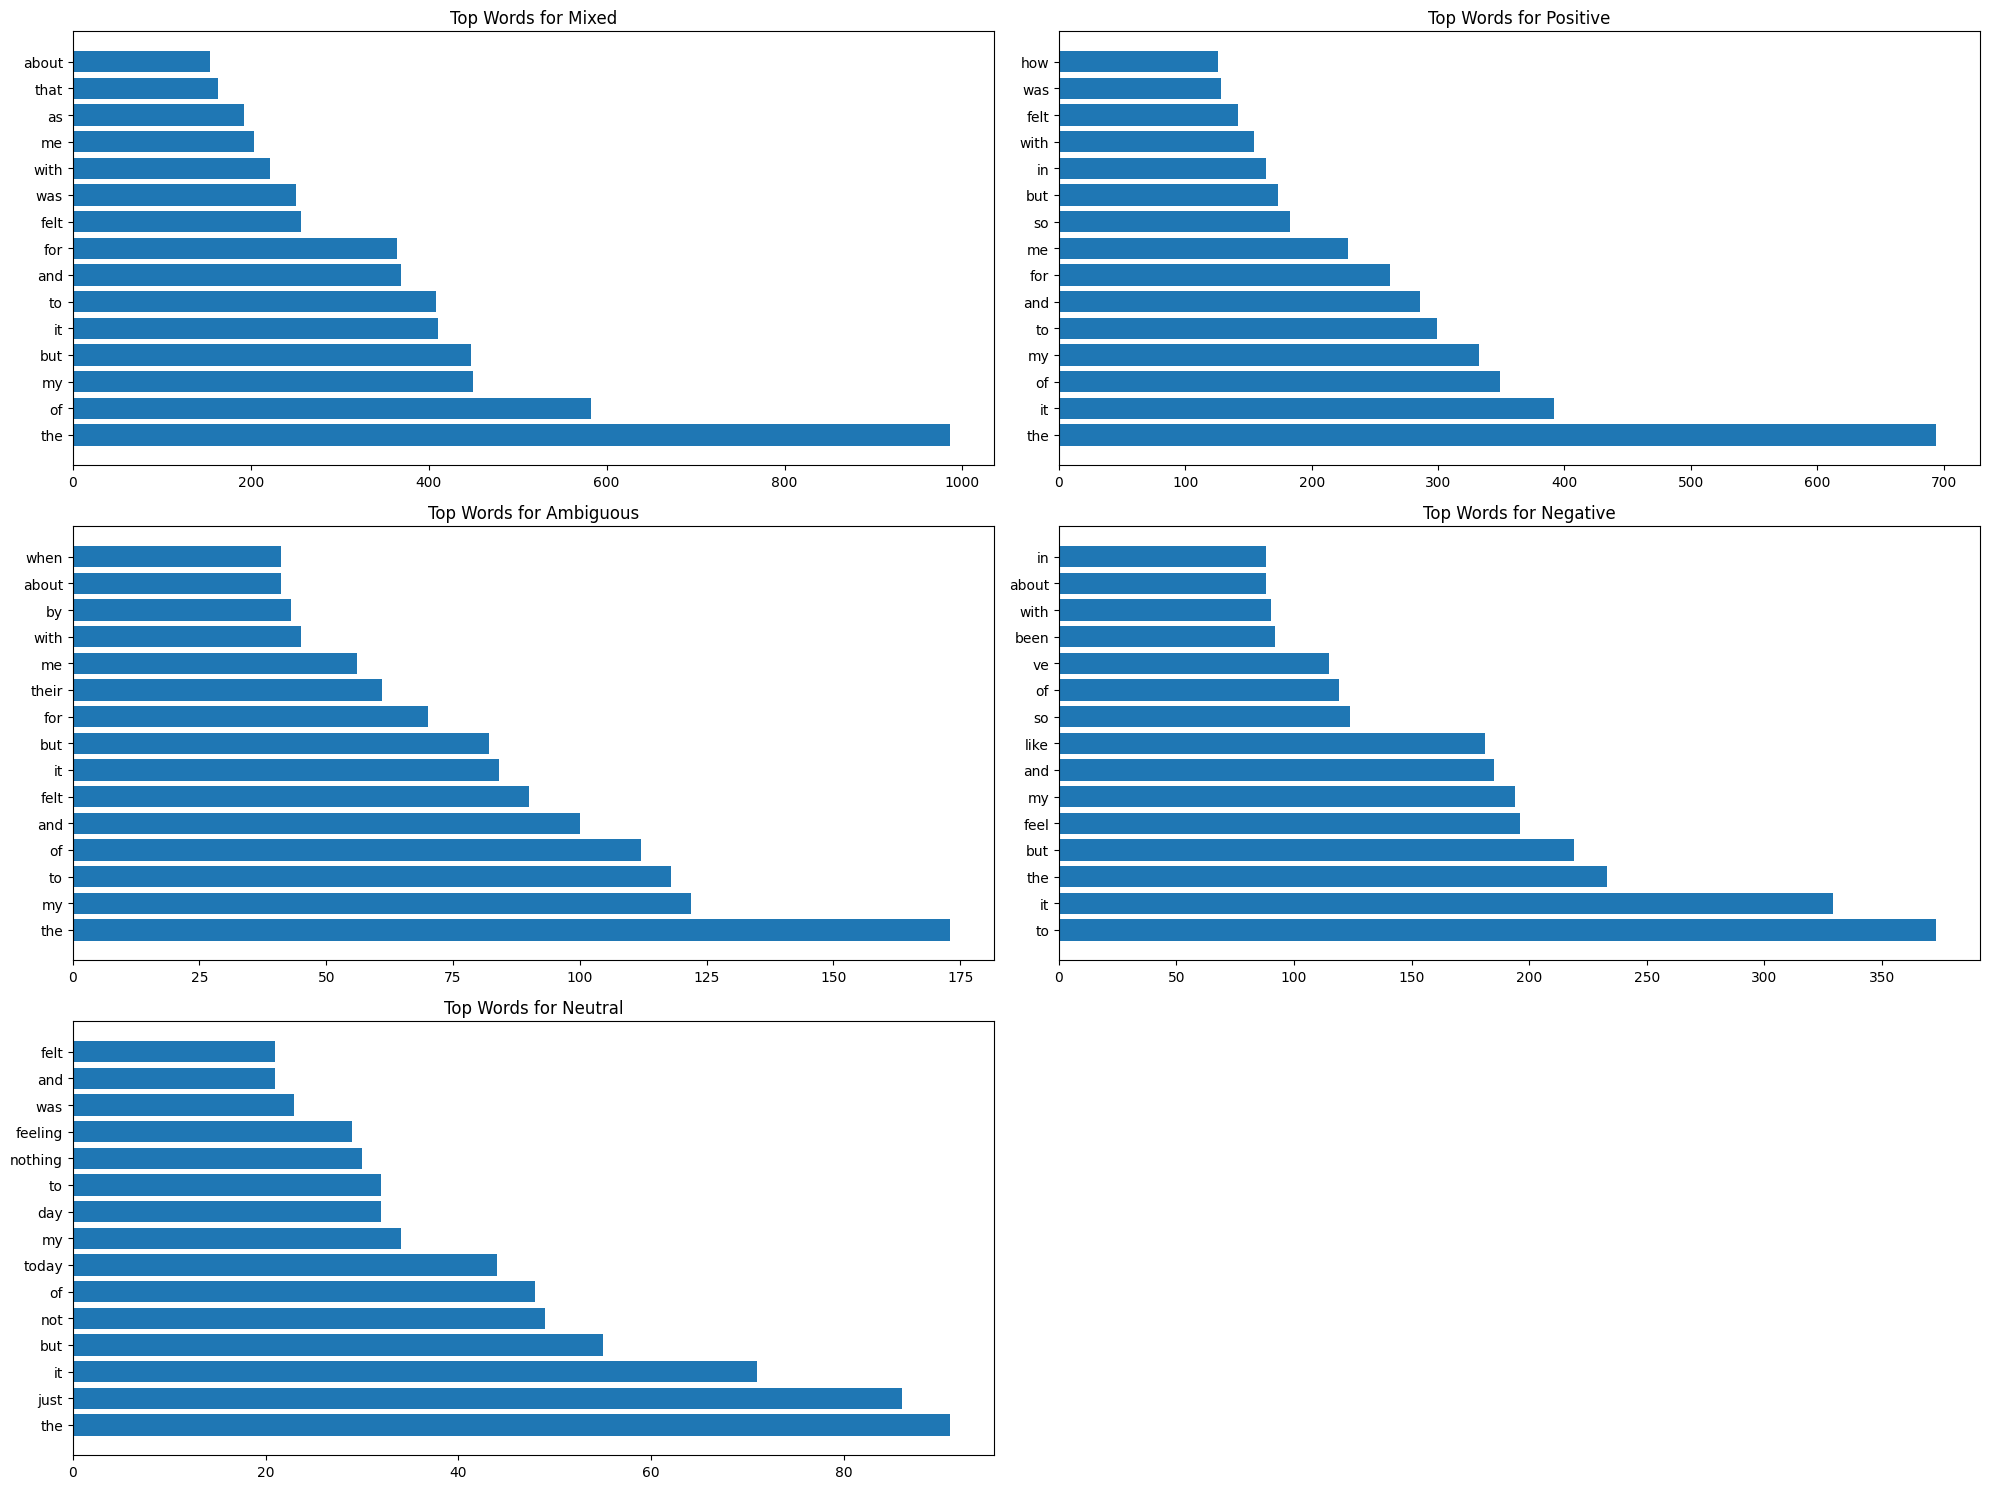

In [5]:
# Plot text length distributions
plot_text_length_distribution(train_df)

# Create overall word cloud
create_wordcloud(train_df['text'].tolist())

# Create word clouds by sentiment
create_class_wordclouds(train_df, text_column='text', class_column='sentiment')

# Get most frequent words
plot_top_n_words(train_df['text'].tolist(), n=30, title='Top 30 Most Common Words')

# Get most frequent words by sentiment
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

sentiments = train_df['sentiment'].unique()
for i, sentiment in enumerate(sentiments):
    if i >= len(axes):
        break
        
    sentiment_texts = train_df[train_df['sentiment'] == sentiment]['text'].tolist()
    
    # Get top words for this sentiment
    top_words = get_top_n_words(sentiment_texts, n=15)
    words, counts = zip(*top_words)
    
    axes[i].barh(range(len(words)), counts, align='center')
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].set_title(f'Top Words for {sentiment}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

### Now without the stopwords

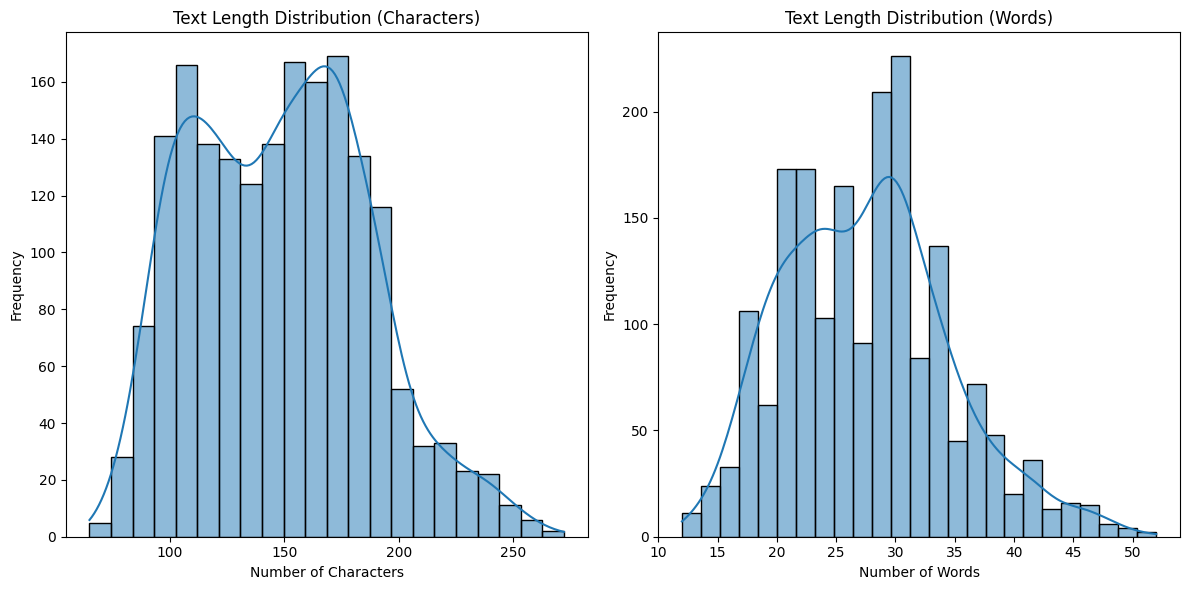

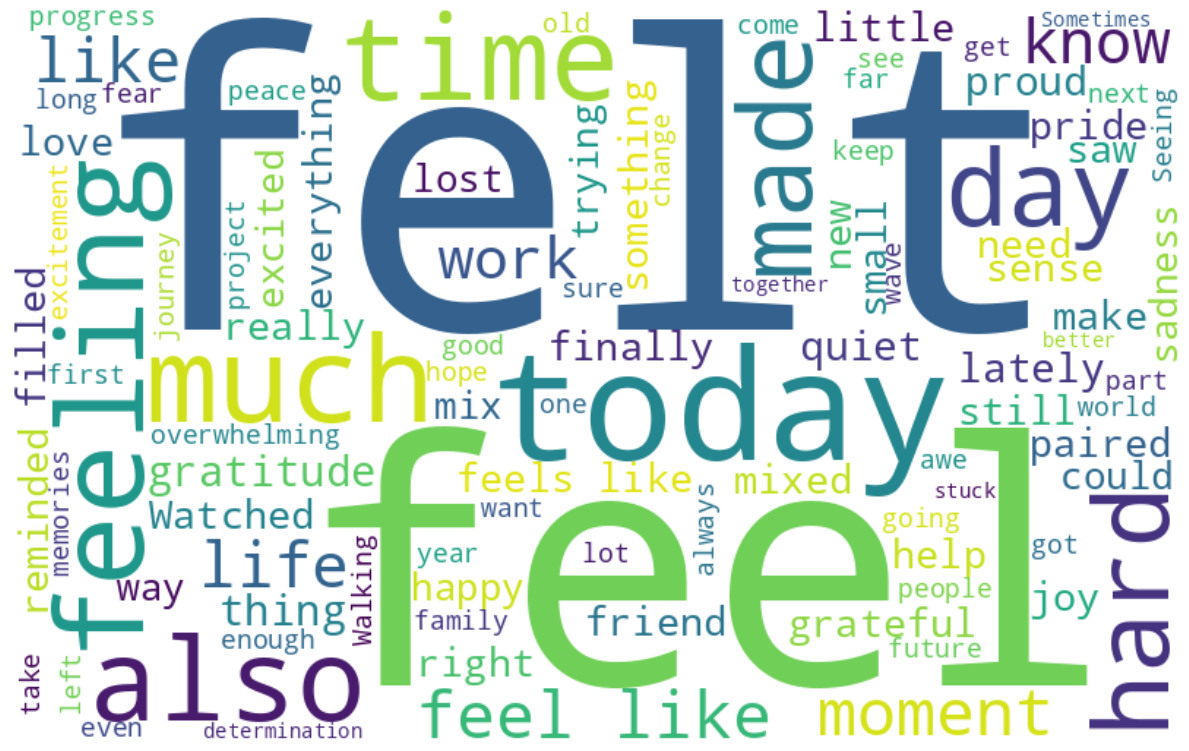

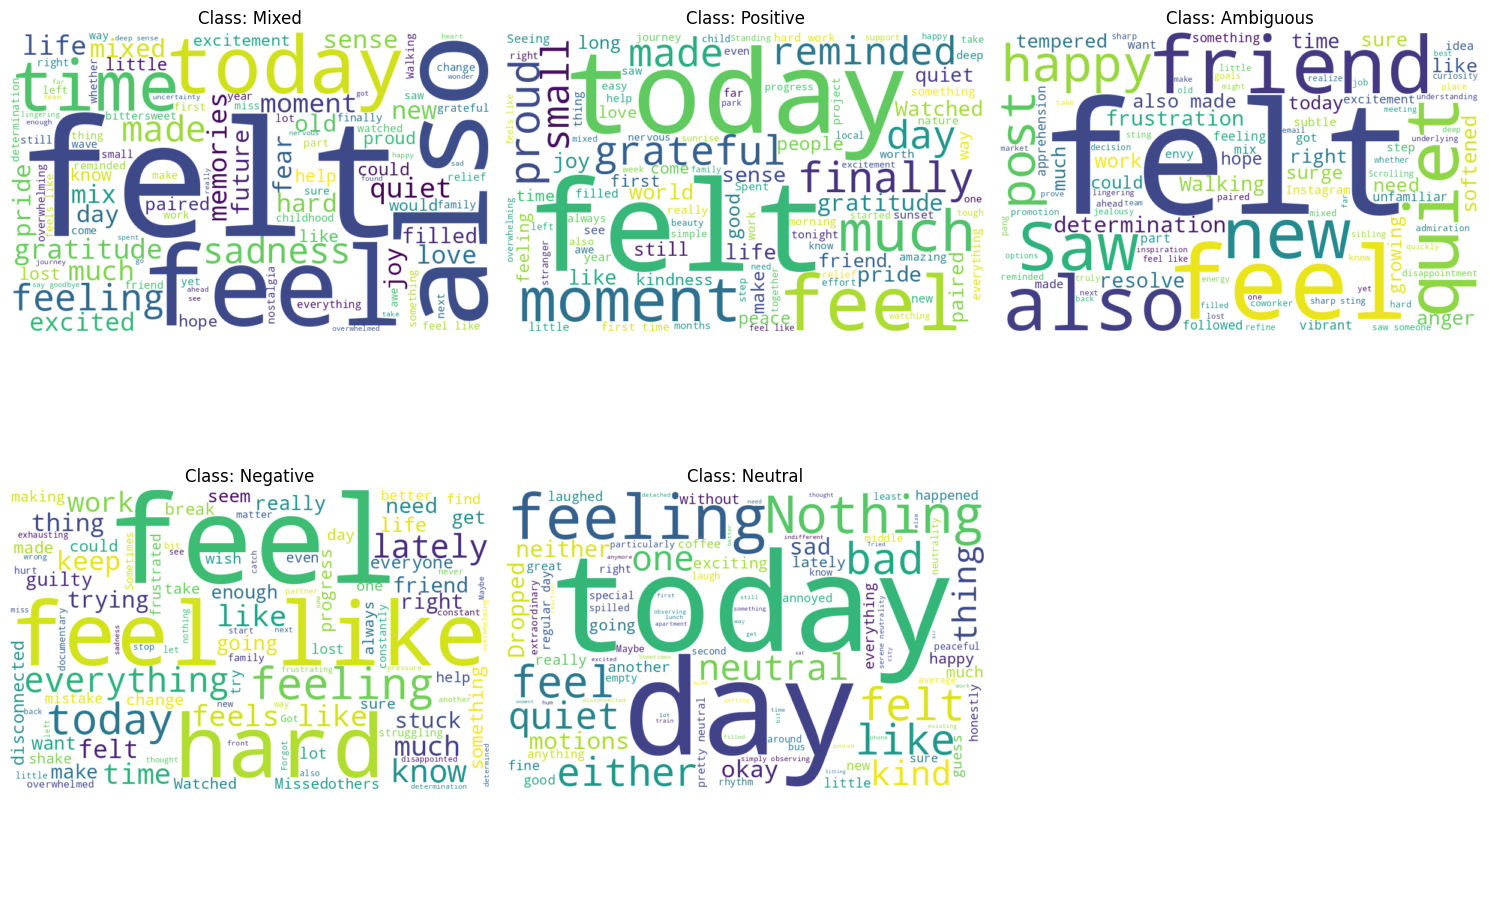

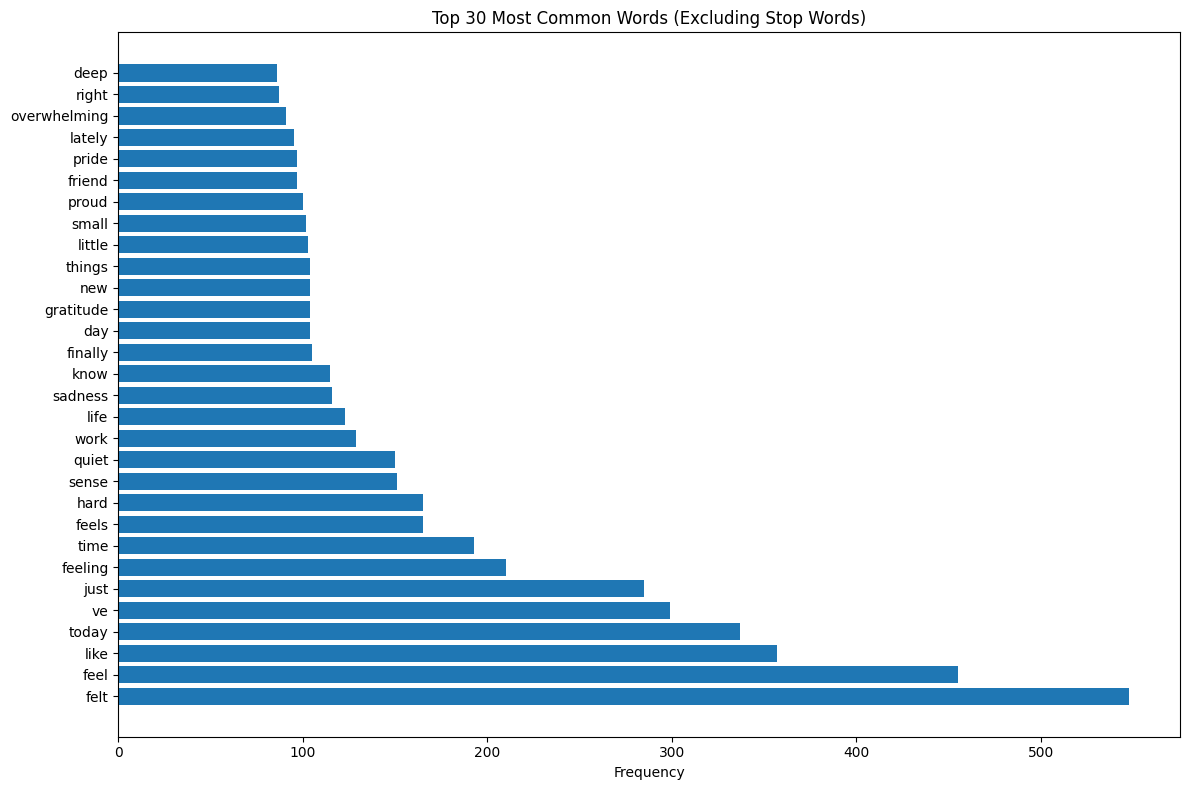

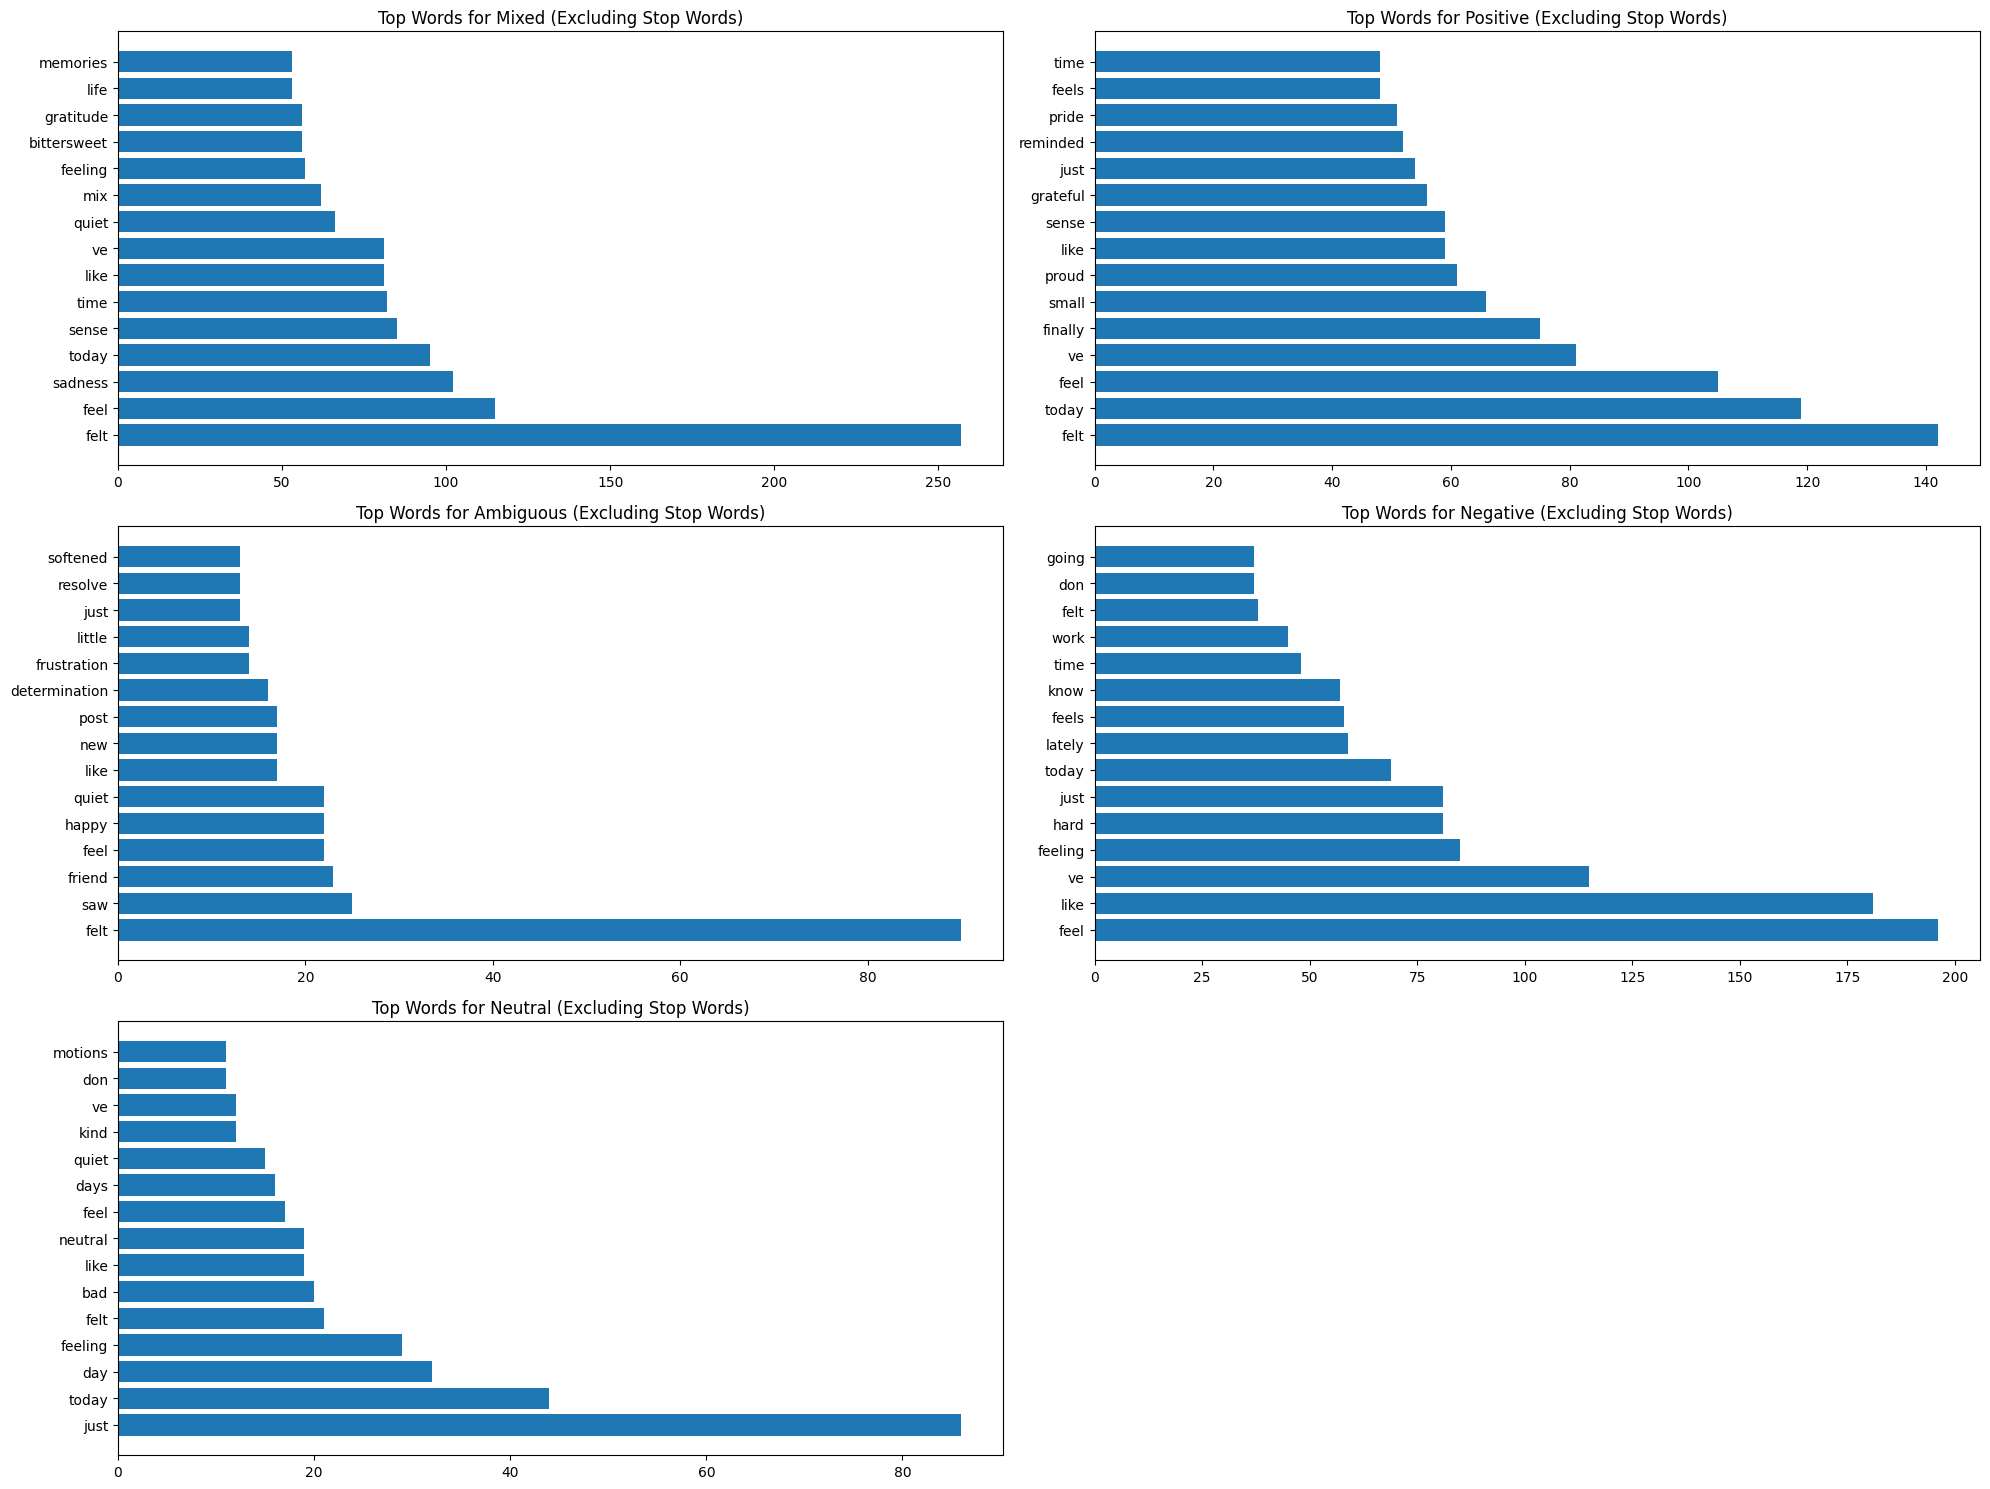

In [11]:
# Import NLTK's English stop words
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Get stop words as a LIST (not a set) - this is the key fix
stop_words_list = list(stopwords.words('english'))

# Plot text length distributions
plot_text_length_distribution(train_df)

# Create overall word cloud without stop words
create_wordcloud(train_df['text'].tolist(), stop_words=stop_words_list)

# Create word clouds by sentiment without stop words
create_class_wordclouds(train_df, text_column='text', class_column='sentiment', stop_words=stop_words_list)

# Get most frequent words without stop words
top_words = get_top_n_words(train_df['text'].tolist(), n=30, stop_words='english')
words, counts = zip(*top_words)

plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, align='center')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 30 Most Common Words (Excluding Stop Words)')
plt.tight_layout()
plt.show()

# Get most frequent words by sentiment without stop words
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

sentiments = train_df['sentiment'].unique()
for i, sentiment in enumerate(sentiments):
    if i >= len(axes):
        break
        
    sentiment_texts = train_df[train_df['sentiment'] == sentiment]['text'].tolist()
    
    # Get top words for this sentiment without stop words
    top_words = get_top_n_words(sentiment_texts, n=15, stop_words='english')
    words, counts = zip(*top_words)
    
    axes[i].barh(range(len(words)), counts, align='center')
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].set_title(f'Top Words for {sentiment} (Excluding Stop Words)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

# Relationships beteween features

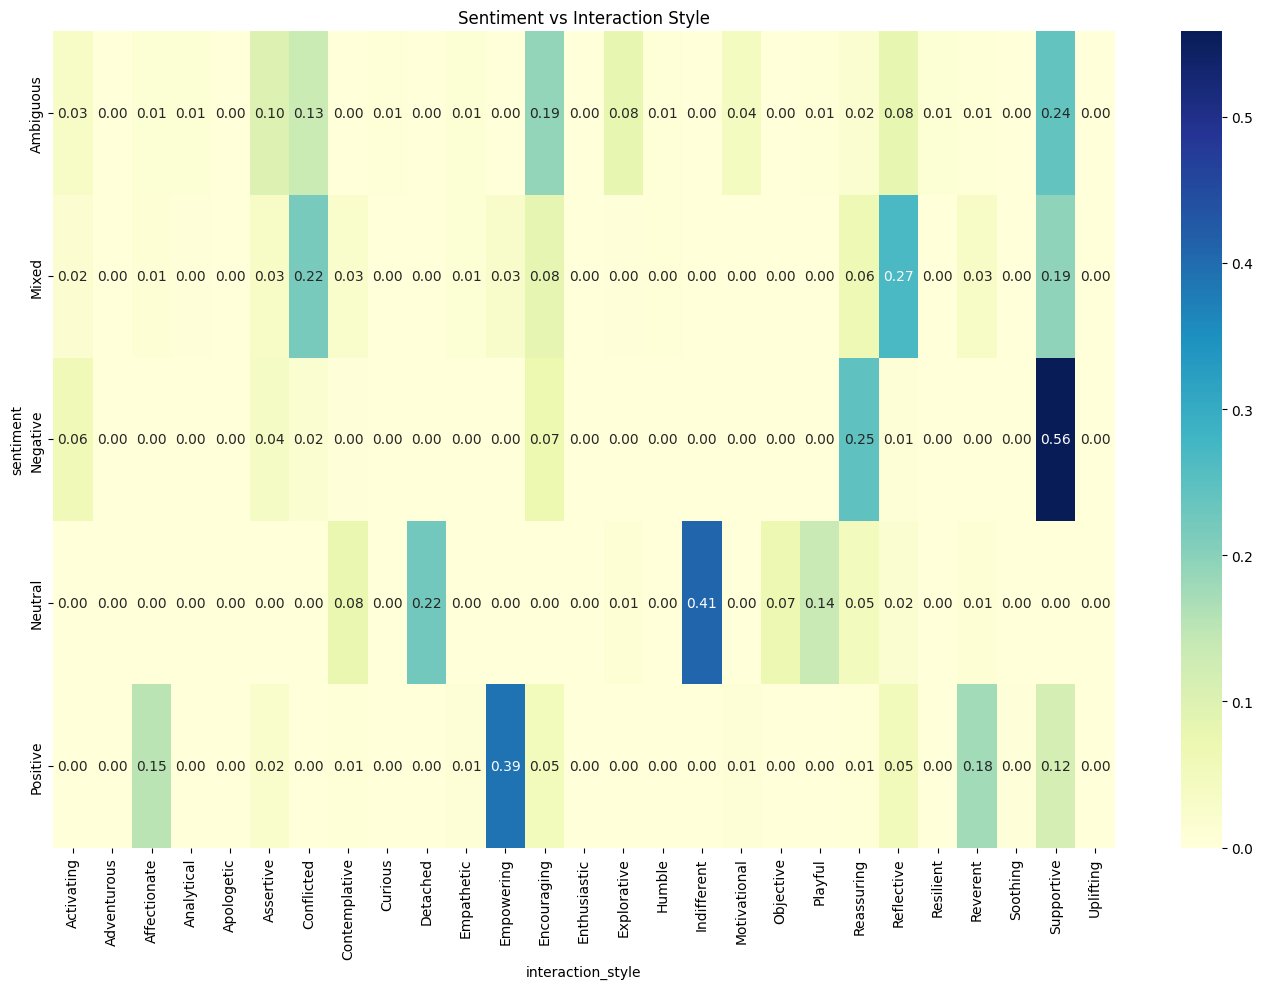

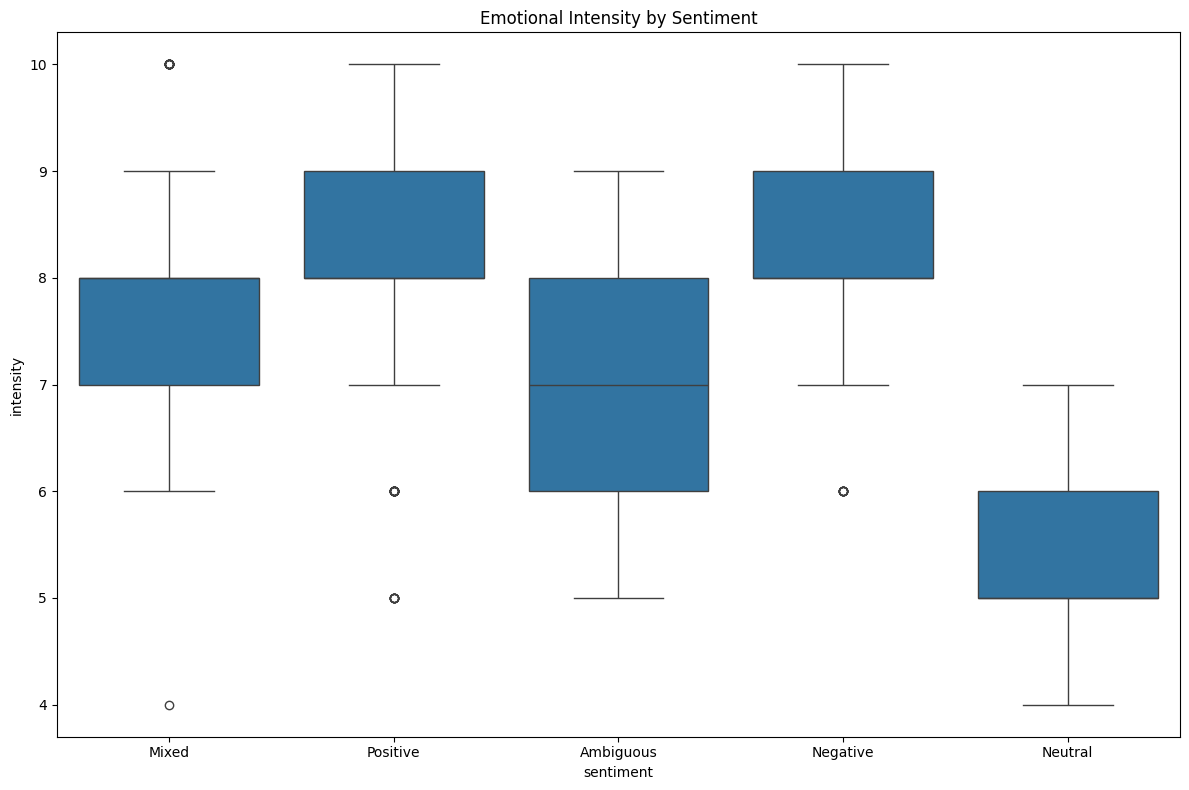

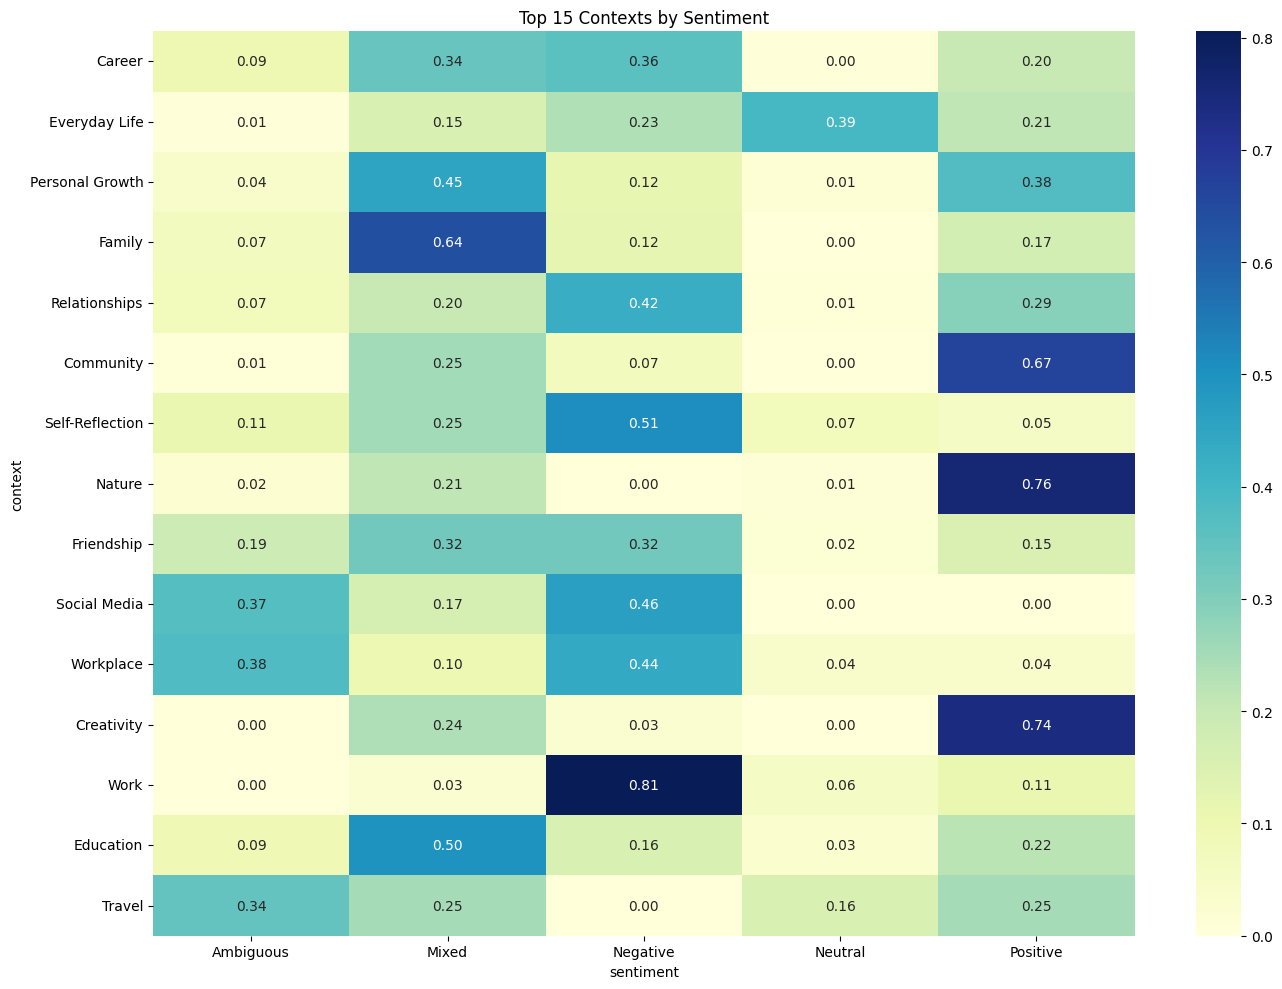

In [ ]:
# Relationship between sentiment and interaction style
plt.figure(figsize=(14, 10))
cross_tab = pd.crosstab(train_df['sentiment'], train_df['interaction_style'], normalize='index')
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Sentiment vs Interaction Style')
plt.tight_layout()
plt.show()

# Relationship between sentiment and intensity
plt.figure(figsize=(12, 8))
sns.boxplot(x='sentiment', y='intensity', data=train_df)
plt.title('Emotional Intensity by Sentiment')
plt.tight_layout()
plt.show()

# Top contexts by sentiment
plt.figure(figsize=(14, 10))
context_by_sentiment = pd.crosstab(train_df['context'], train_df['sentiment'])
# Normalize to get percentages
context_by_sentiment_norm = context_by_sentiment.div(context_by_sentiment.sum(axis=1), axis=0)
# Get top 15 contexts by total count
top_contexts = context_by_sentiment.sum(axis=1).nlargest(15).index
sns.heatmap(context_by_sentiment_norm.loc[top_contexts], annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Top 15 Contexts by Sentiment')
plt.tight_layout()
plt.show()